In [1]:
import pandas as pd


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### 행-열 전치

In [2]:
df = pd.read_csv('./tuned_parameters.csv')
df_transposed = df.T
df_transposed.columns = df_transposed.iloc[0]
df_transposed.drop(df_transposed.index[0], inplace=True)
# df_transposed.drop("Unnamed: 0", axis=1, inplace=True)
df_transposed.to_csv('./tuned_parameters_temp.csv')
df_transposed = pd.read_csv('./tuned_parameters_temp.csv')
df_transposed = df_transposed.drop(["Unnamed: 0", "Accumulated Coverage"], axis=1)
df_transposed


,disable-inlining,max-memory-inhibit,klee-call-optimisation,use-construct-hash-stp,use-visitor-hash,equality-substitution,check-overshift,check-div-zero,use-branch-cache,use-independent-solver,...,array-value-ratio,search,switch-type,smtlib-display-constants,smtlib-abbreviation-mode,seed-file,sym-arg,sym-files,sym-stdin,Coverage
0,False,True,True,True,True,True,True,True,True,True,...,1.000000,random-path,internal,dec,let,1,15,1 8,8,1399
1,True,True,False,False,True,True,False,True,True,False,...,0.579563,nurs:cpicnt,simple,dec,none,8,15,2 23,8,1318
2,True,True,False,False,False,True,True,False,True,False,...,0.084122,random-state,internal,bin,let,9,20,2 1,12,1114
3,False,True,False,True,True,True,True,True,True,False,...,0.385358,random-path,llvm,hex,none,6,13,2 20,6,1055
4,False,False,True,True,True,False,False,True,True,False,...,0.921644,nurs:qc,llvm,hex,none,8,18,2 28,14,875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,True,True,False,True,True,True,True,False,True,True,...,0.209984,nurs:icnt,simple,bin,none,3,13,1 30,9,1440
2196,True,False,True,True,True,True,False,True,True,True,...,0.275574,dfs,simple,bin,none,3,24,2 17,146,1656
2197,False,True,True,True,True,False,True,True,False,True,...,0.436098,nurs:icnt,simple,bin,none,4,13,2 3,146,1766
2198,False,True,False,True,True,False,True,True,True,False,...,0.209984,dfs,simple,bin,none,4,4,2 30,4,1516


In [101]:
# 문자열 데이터만 선택
string_columns = df_transposed.select_dtypes(include=['object'])

string_columns.columns

Index(['seed-time', 'max-solver-time', 'batch-time',
       'uncovered-update-interval', 'search', 'switch-type',
       'smtlib-display-constants', 'smtlib-abbreviation-mode', 'sym-files'],
      dtype='object')

In [102]:
time = ['seed-time', 'uncovered-update-interval', 'max-solver-time', 'batch-time']
for t in time:
    df_transposed[t] = df_transposed[t].apply(lambda x: str(x).replace('s', ''))
    df_transposed[t] = pd.to_numeric(df_transposed[t], errors='coerce').astype(int)

In [103]:
# 'sym-files' 열을 공백을 기준으로 분리하고 결과를 새로운 열에 할당
df_transposed[['sym-files-1', 'sym-files-2']] = df_transposed['sym-files'].str.split(expand=True)
df_transposed['sym-files-1'] = pd.to_numeric(df_transposed['sym-files-1'], errors='coerce').astype(int)
df_transposed['sym-files-2'] = pd.to_numeric(df_transposed['sym-files-2'], errors='coerce').astype(int)

df2 = df_transposed.drop(["sym-files", "Coverage"], axis=1)
df2["Coverage"] = df_transposed["Coverage"]

In [104]:
# 문자열 데이터만 선택
string_columns = df2.select_dtypes(include=['object'])

string_columns.columns

Index(['search', 'switch-type', 'smtlib-display-constants',
       'smtlib-abbreviation-mode'],
      dtype='object')

In [106]:
df2.to_csv('./dataset.csv', index=False)

In [50]:
import json
df = pd.read_csv('./dataset.csv')
data_list = []
for index, row in df.iterrows():
    config = {}
    for key, value in row.items():
        if key != "Coverage":
            config[key] = value
    data = {
        "id": index,
        "config": config,
        "metric": row["Coverage"]

    }
    data_list.append(data)
    

data_list
json.dump(data_list, open('./ParaSuit.json', 'w'), indent=4)


In [60]:
import json
import pandas as pd
import numpy as np

# 데이터 로드 (예시 데이터프레임 생성)


hyperparameters = []
for key in df.columns:
    
    if key != "Coverage":
        dtype = df[key].dtype
        
        words = key.split('-')

        # 각 단어의 첫 글자를 추출하여 연결
        summary = ''.join(word[0] for word in words)

        if dtype == "int64":
            dtype_str = "numerical"
            valuetype = "int"
            value = [df[key].min(), df[key].max()]
        elif dtype == "float64":
            dtype_str = "numerical"
            valuetype = "float"
            value = [df[key].min(), df[key].max()]
        elif dtype == "object":
            dtype_str = "categorical"
            valuetype = "string"
            value = df[key].unique().tolist()
        elif dtype == "bool":
            dtype_str = "boolean"
            valuetype = "boolean"
            value = df[key].unique().tolist()
            
        hyperparameter = {
            "name": key,
            "displayName": summary.upper(),
            "value": value,
            "type": dtype_str,
            "valueType": valuetype
        }
        hyperparameters.append(hyperparameter)

config_json = {
    "name": "ParaSuit",
    "hyperparameters": hyperparameters,
    "metric": {
        "name": "Coverage",
        "displayName": "CVRG"
    }
}

# JSON 파일로 저장
with open('./config.json', 'w') as f:
    json.dump(config_json, f, indent=4)


### 학습


In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

import xgboost as xgb

# 데이터 로드
data = pd.read_csv('dataset.csv')

# 특성(X)과 타겟(y) 분리
X = data.drop(['Coverage'], axis=1)
y = data['Coverage']



# y값에 로그 변환 적용 (0값 처리를 위해 1을 더함)
y = np.log1p(y)


# 레이블 인코딩 적용
le = LabelEncoder()
categorical_columns = list(X.select_dtypes(include=['object']).columns)
for col in categorical_columns:
    X[col] = le.fit_transform(X[col])
    

scaler = StandardScaler()
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
    X[col] = scaler.fit_transform(X[col].values.reshape(-1, 1))

# 입력 변수와 타겟 변수 분리




# 데이터를 train/val/test 세트로 분할 (비율: 7:2:1)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)



print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)


# 데이터 분할 (학습 데이터와 테스트 데이터)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost 모델 학습
model = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=1000, learning_rate=0.01, random_state=20)
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 모델 평가 (로그 스케일)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Mean squared error (log scale): {mse}")
print(f"R-squared score (log scale): {r2}")

# 원래 스케일로 변환하여 평가

y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

mse_original = mean_squared_error(y_test_exp, y_pred_exp)
r2_original = r2_score(y_test_exp, y_pred_exp)

print(f"\nMean squared error (original scale): {mse_original}")
print(f"R-squared score (original scale): {r2_original}")

# 특성 중요도 출력
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print("\nTop 10 important features:")
print(feature_importance.head(10)) 

Train set shape: (1584, 61) (1584,)
Validation set shape: (396, 61) (396,)
Test set shape: (220, 61) (220,)
Mean squared error (log scale): 0.42867001621747863
R-squared score (log scale): 0.6702902478225633

Mean squared error (original scale): 82635.8042202338
R-squared score (original scale): 0.5882310598442457

Top 10 important features:
                      feature  importance
53                switch-type    0.239342
29             disable-verify    0.211405
2      klee-call-optimisation    0.061876
6             check-overshift    0.051348
34                verify-each    0.046795
0            disable-inlining    0.039563
26          cex-cache-try-all    0.031652
56                  seed-file    0.028275
45  uncovered-update-interval    0.017311
4            use-visitor-hash    0.015596


In [39]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

[23:46:57] WARNING: /var/folders/c_/qfmhj66j0tn016nkx_th4hxm0000gp/T/abs_d6q0e1lomi/croot/xgboost-split_1713972719224/work/cpp_src/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


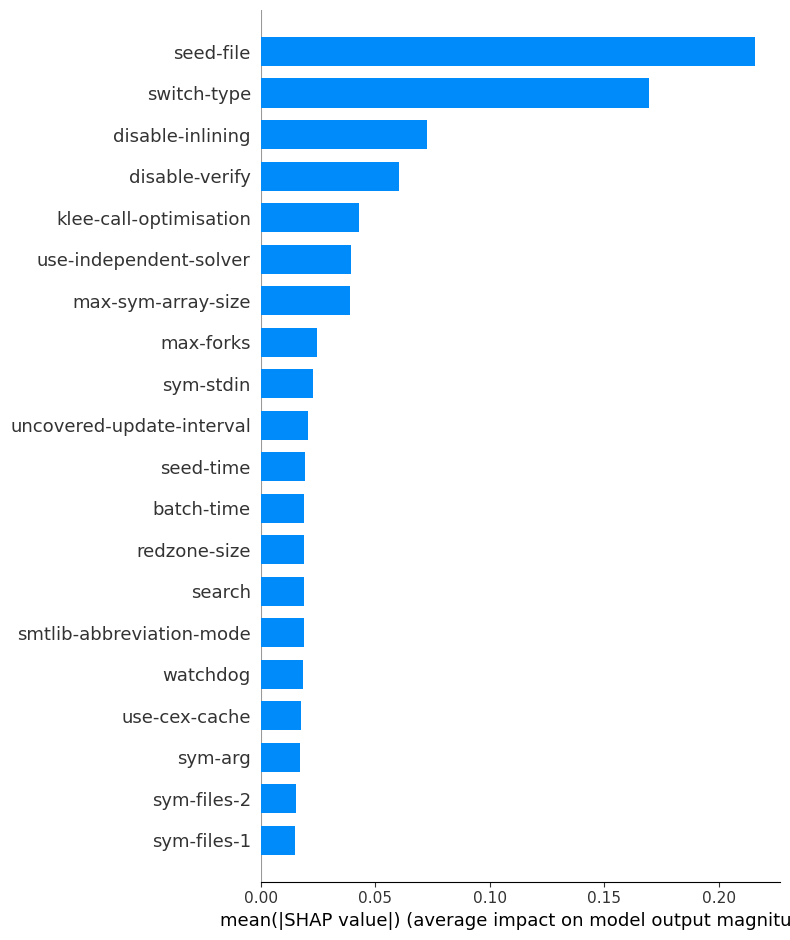

In [41]:
shap.summary_plot(shap_values, X, plot_type="bar")

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


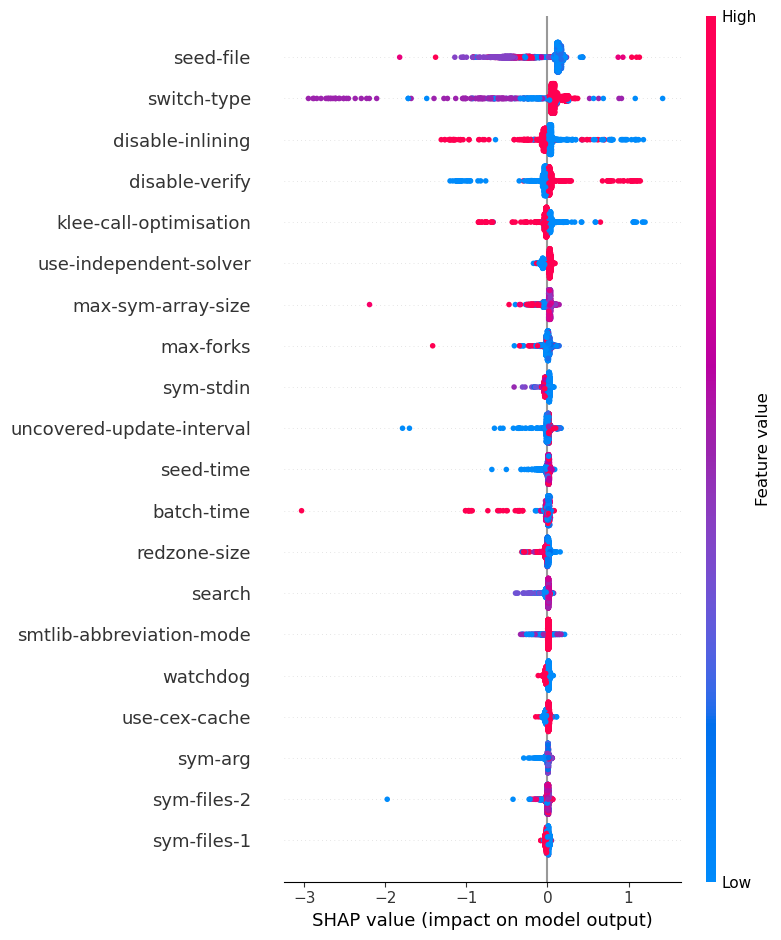

In [44]:
shap.summary_plot(shap_values, X)

In [47]:
df = pd.DataFrame(shap_values, columns=X.columns)
df.to_json('shap_values.json', orient='records')


### set 데이터셋 정제

In [24]:
import pandas as pd
import numpy as np
# 데이터 읽기
file = open('coverage_set.txt', 'r')
data = file.read()
with open('coverage_set.txt', 'r') as file:
    data = file.read()
    text_trials = data.split("\n")
    # print("trials", trials[0])
    trials = []
    for trial in text_trials:
        
        trial = trial.strip("{}").split(", ")
        if len(trial) == 1 and trial[0] == '':
            trials.append([])
        else:
            trial = [int(t) for t in trial]
            trials.append(trial)

# trials = np.array(trials)
# trials.shape()


In [29]:
# 모든 유니크한 숫자 찾기
all_numbers = sorted(set(num for trial in trials for num in trial))
print(max(all_numbers))
len(all_numbers)


3365


3365

In [30]:
# 모든 유니크한 숫자 찾기
all_numbers = sorted(set(num for trial in trials for num in trial))

# DataFrame 생성
df = pd.DataFrame(index=range(len(trials)), columns=all_numbers)

# DataFrame 채우기
for i, trial in enumerate(trials):
    df.loc[i] = [1 if num in trial else 0 for num in all_numbers]

# 결과 확인
print(df.head())
print(f"\nDataFrame shape: {df.shape}")

  1    2    3    4    5    6    7    8    9    10    ... 3356 3357 3358 3359  \
0    1    1    1    1    1    1    1    1    1    1  ...    0    0    0    0   
1    1    0    1    1    1    1    1    1    0    1  ...    0    0    0    0   
2    1    1    1    1    1    1    1    1    0    1  ...    0    0    0    0   
3    1    1    1    1    1    1    1    1    0    1  ...    0    0    0    0   
4    1    0    1    1    1    1    1    1    0    1  ...    0    0    0    0   

  3360 3361 3362 3363 3364 3365  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 3365 columns]

DataFrame shape: (2201, 3365)


In [31]:
df.to_csv('coverage_set.csv', index=False)

In [41]:
df = pd.read_csv('coverage_set.csv')
df

,1,2,3,4,5,6,7,8,9,10,...,3356,3357,3358,3359,3360,3361,3362,3363,3364,3365
0,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2196,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2197,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2198,1,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


/opt/anaconda3/envs/swt/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


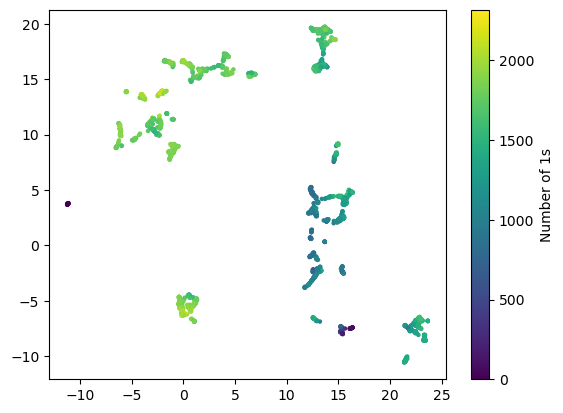

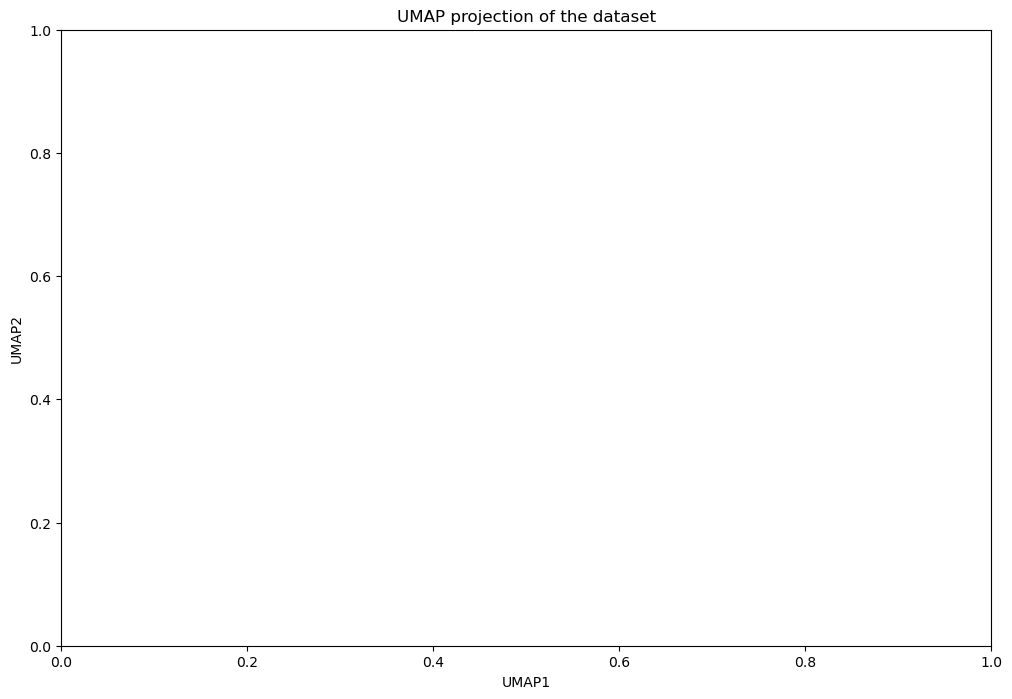

In [45]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
# 데이터 준비
X = df.values
# 각 trial의 1의 개수 계산
ones_count = X.sum(axis=1)

# UMAP 모델 생성 및 학습
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X)
# 색상 정규화
norm = Normalize(vmin=ones_count.min(), vmax=ones_count.max())

scatter = plt.scatter(embedding[:, 0], embedding[:, 1], 
                      c=ones_count, cmap='viridis', 
                      s=5, norm=norm)

# 결과 시각화
plt.figure(figsize=(12, 8))
plt.colorbar(scatter, label='Number of 1s')
plt.title('UMAP projection of the dataset')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

In [47]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

def jaccard_distance(a, b):
    intersection = np.logical_and(a, b)
    union = np.logical_or(a, b)
    union_sum = union.sum()
    if union_sum == 0:
        return 0.0  # 두 벡터가 모두 0일 때
    return 1.0 - intersection.sum() / union_sum

# 데이터 준비 (예: df는 각 행이 하나의 trial을 나타내는 DataFrame)
X = df.values

# 모든 trial 쌍에 대해 자카드 거리 계산
distances = pdist(X, metric=jaccard_distance)

# 거리 행렬로 변환
distance_matrix = squareform(distances)

print(distance_matrix)

[[0.         0.38657957 0.38703466 ... 0.33858268 0.36786114 0.30140056]
 [0.38657957 0.         0.30876217 ... 0.41683778 0.28450363 0.36328342]
 [0.38703466 0.30876217 0.         ... 0.45659164 0.36544438 0.40011648]
 ...
 [0.33858268 0.41683778 0.45659164 ... 0.         0.34158666 0.14566285]
 [0.36786114 0.28450363 0.36544438 ... 0.34158666 0.         0.26882903]
 [0.30140056 0.36328342 0.40011648 ... 0.14566285 0.26882903 0.        ]]


In [48]:
print(np.isnan(distance_matrix).sum())
print(np.where(np.isnan(distance_matrix)))

0
(array([], dtype=int64), array([], dtype=int64))


In [ ]:
max_distance = np.nanmax(distance_matrix)
distance_matrix_filled = np.nan_to_num(distance_matrix, nan=max_distance)

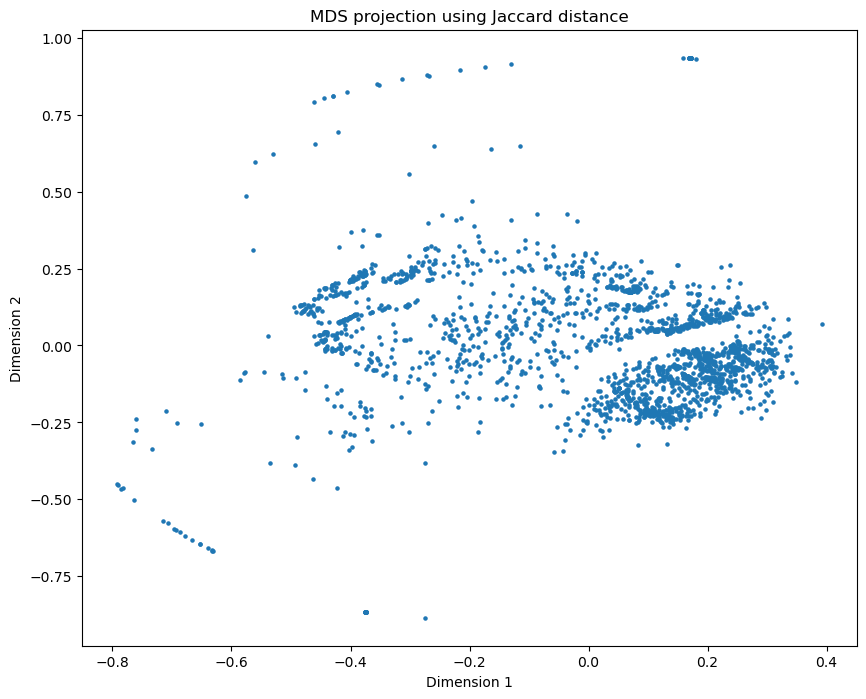

In [49]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# MDS 수행
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
positions = mds.fit_transform(distance_matrix)

# 결과 시각화
plt.figure(figsize=(10, 8))
plt.scatter(positions[:, 0], positions[:, 1], s=5)
plt.title('MDS projection using Jaccard distance')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

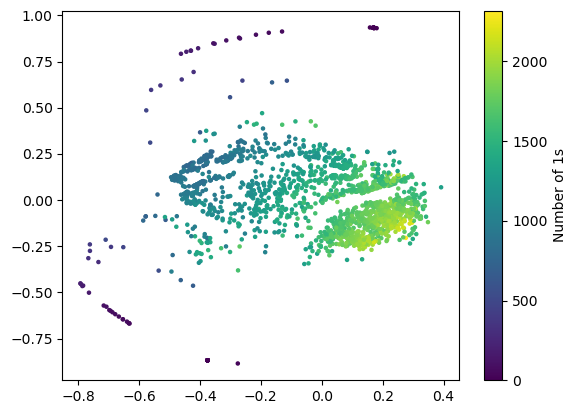

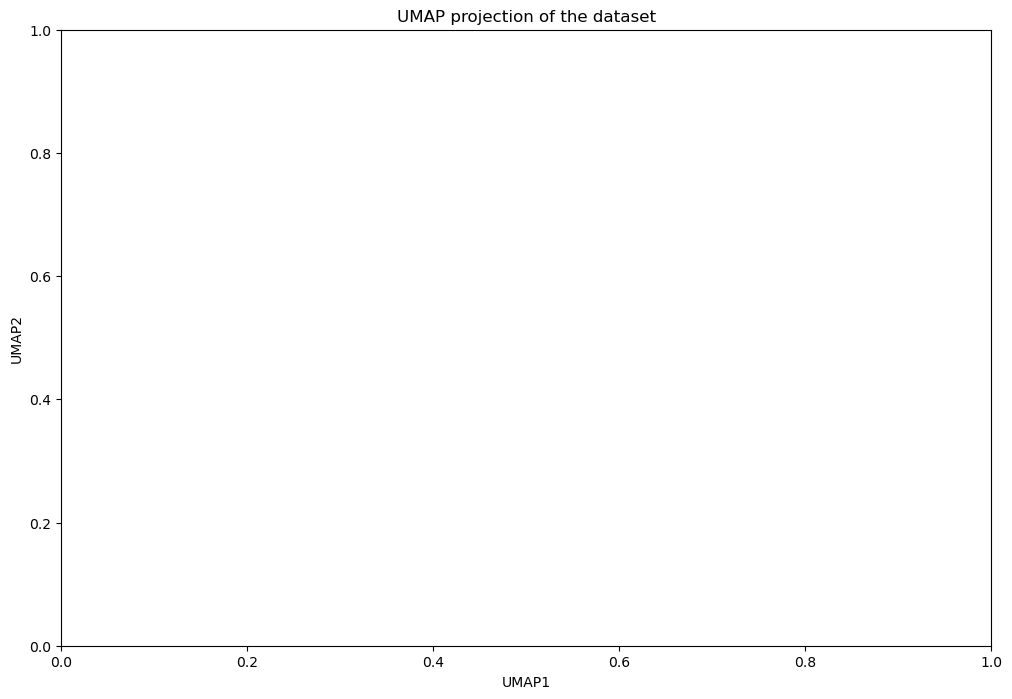

In [50]:

# 색상 정규화
norm = Normalize(vmin=ones_count.min(), vmax=ones_count.max())

scatter = plt.scatter(positions[:, 0], positions[:, 1], 
                      c=ones_count, cmap='viridis', 
                      s=5, norm=norm)

# 결과 시각화
plt.figure(figsize=(12, 8))
plt.colorbar(scatter, label='Number of 1s')
plt.title('UMAP projection of the dataset')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()